## Глава 3. Анализ изображений: Детекция повреждений дорожного покрытия
### Этапы первичного анализа: фильтрация, парсинг аннотаций и визуализация

В данной ячейке выполняется сканирование распакованного набора данных Potholes Detection. Скрипт осуществляет строгую алгоритмическую фильтрацию графических файлов по размеру. Изображения с шириной или высотой менее пятисот двенадцати пикселей отбраковываются для строгого соблюдения технических требований учебно-методического материала.

Далее код считывает текстовые файлы разметки формата YOLO для первого валидного снимка. Относительные нормализованные координаты центров ям математически пересчитываются в абсолютные пиксельные значения. Итоговым результатом работы скрипта является наглядная визуализация дорожного полотна с наложенными ограничивающими прямоугольниками поверх обнаруженных дефектов.

ПРОВЕРКА ОПТИЧЕСКОГО РАЗРЕШЕНИЯ
Всего обработано изображений: 1581
Допущено к анализу (>= 512x512): 483
Отбраковано из-за низкого разрешения: 1098
ВИЗУАЛИЗАЦИЯ ДЕТЕКЦИИ


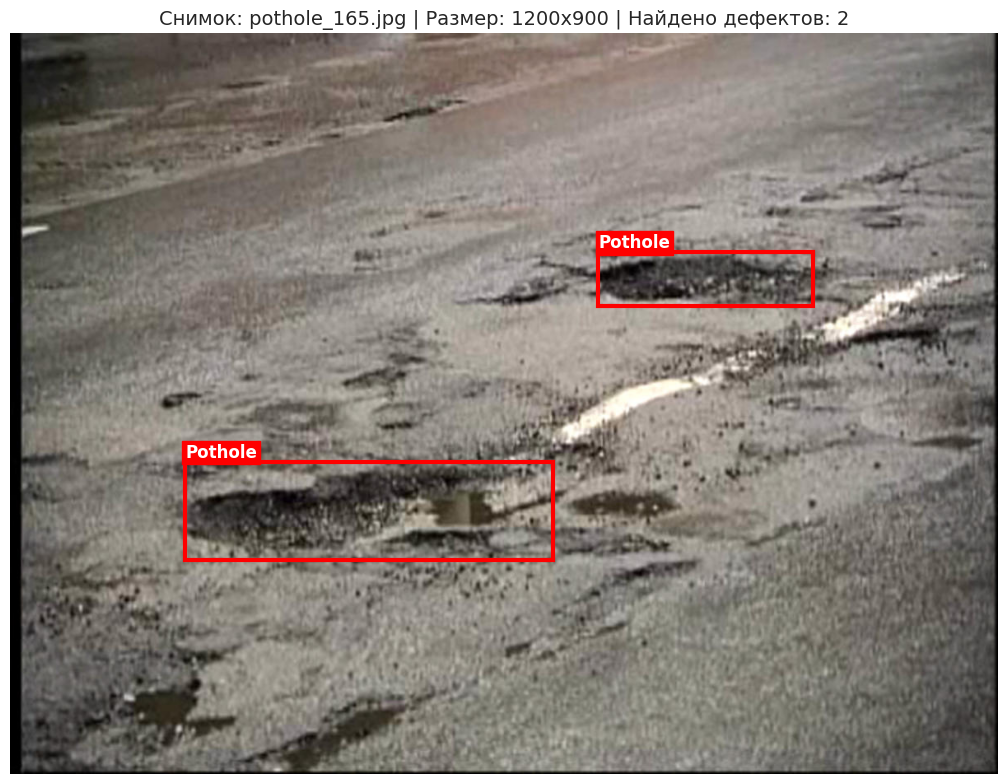

In [ ]:
import os
import glob
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sb

sb.set_theme(style="whitegrid", rc={"axes.spines.top": False, "axes.spines.right": False})

# Пути к тренировочной выборке
IMAGES_DIR = '/content/drive/MyDrive/archive/train/images'
LABELS_DIR = '/content/drive/MyDrive/archive/train/labels'

# 1. Фильтрация по разрешению >= 512x512
valid_images = []
discarded_images = 0

if os.path.exists(IMAGES_DIR) and os.path.exists(LABELS_DIR):
    all_images = glob.glob(os.path.join(IMAGES_DIR, '*.jpg'))

    for img_path in all_images:
        with Image.open(img_path) as img:
            w, h = img.size
            if w >= 512 and h >= 512:
                valid_images.append({'path': img_path, 'width': w, 'height': h})
            else:
                discarded_images += 1

    print("ПРОВЕРКА ОПТИЧЕСКОГО РАЗРЕШЕНИЯ")
    print(f"Всего обработано изображений: {len(all_images)}")
    print(f"Допущено к анализу (>= 512x512): {len(valid_images)}")
    print(f"Отбраковано из-за низкого разрешения: {discarded_images}")

    if len(valid_images) == 0:
        print("Нет изображений, удовлетворяющих правилу 512x512.")
    else:
        # 2. Анализ разметки и визуализация типичного изображения
        print("ВИЗУАЛИЗАЦИЯ ДЕТЕКЦИИ")

        # Берем первый валидный снимок
        sample = valid_images[0]
        img_path = sample['path']
        img_filename = os.path.basename(img_path)
        label_filename = img_filename.replace('.jpg', '.txt')
        label_path = os.path.join(LABELS_DIR, label_filename)

        # Загружаем картинку для отрисовки
        img = Image.open(img_path)
        img_w, img_h = img.size

        fig, ax = plt.subplots(1, 1, figsize=(12, 8))
        ax.imshow(img)

        # Парсинг YOLO аннотаций
        bboxes_count = 0
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                lines = f.readlines()
                for line in lines:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        bboxes_count += 1
                        class_id = int(parts[0])
                        x_center_norm = float(parts[1])
                        y_center_norm = float(parts[2])
                        width_norm = float(parts[3])
                        height_norm = float(parts[4])

                        # Перевод нормализованных координат в абсолютные пиксели
                        box_w = width_norm * img_w
                        box_h = height_norm * img_h
                        x_top_left = (x_center_norm * img_w) - (box_w / 2)
                        y_top_left = (y_center_norm * img_h) - (box_h / 2)

                        # Отрисовка прямоугольника
                        rect = patches.Rectangle(
                            (x_top_left, y_top_left), box_w, box_h,
                            linewidth=3, edgecolor='red', facecolor='none'
                        )
                        ax.add_patch(rect)

                        # Подпись над прямоугольником
                        ax.text(x_top_left, y_top_left - 5, 'Pothole',
                                color='white', fontsize=12, fontweight='bold',
                                bbox=dict(facecolor='red', edgecolor='red', pad=2))

        ax.set_title(f"Снимок: {img_filename} | Размер: {img_w}x{img_h} | Найдено дефектов: {bboxes_count}", fontsize=14)
        ax.axis('off')
        plt.tight_layout()
        plt.show()

else:
    print("Директории с данными не найдены.")